In [2]:
# ==========================================
# 1. INSTALASI DEPENDENCY UTAMA
# ==========================================
!pip install pandas numpy pyarrow matplotlib seaborn

     ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
     ---------------------------------------- 0.1/11.3 MB 2.6 MB/s eta 0:00:05
      --------------------------------------- 0.3/11.3 MB 3.4 MB/s eta 0:00:04
     --- ------------------------------------ 1.0/11.3 MB 7.9 MB/s eta 0:00:02
     ------- -------------------------------- 2.0/11.3 MB 14.5 MB/s eta 0:00:01
     -------- ------------------------------- 2.3/11.3 MB 11.1 MB/s eta 0:00:01
     --------- ------------------------------ 2.7/11.3 MB 11.7 MB/s eta 0:00:01
     ------------ --------------------------- 3.6/11.3 MB 13.4 MB/s eta 0:00:01
     ------------- -------------------------- 3.9/11.3 MB 12.4 MB/s eta 0:00:01
     -------------- ------------------------- 4.2/11.3 MB 11.8 MB/s eta 0:00:01
     ---------------- ----------------------- 4.6/11.3 MB 11.7 MB/s eta 0:00:01
     ------------------ --------------------- 5.4/11.3 MB 12.7 MB/s eta 0:00:01
     ------------------- -------------------- 5.6/1


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Administrator\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [11]:
# ==========================================
# 2. IMPORT LIBRARY & FUNGSI UTAMA
# ==========================================
import pandas as pd
import numpy as np

def proses_data_instrumen(filepath):
    """
    Fungsi modular untuk membaca file, standarisasi kolom, 
    mengatur index waktu, dan menghitung indikator teknikal.
    """
    # Deteksi jenis file (.parquet atau .csv)
    if filepath.endswith('.parquet'):
        df = pd.read_parquet(filepath)
    else:
        df = pd.read_csv(filepath)
        
    # Standarisasi nama kolom ke huruf kecil
    df.columns = [str(col).lower() for col in df.columns]
    
    # Deteksi kolom waktu dan jadikan Index
    for col_waktu in ['datetime', 'date', 'time', 'timestamp']:
        if col_waktu in df.columns:
            df[col_waktu] = pd.to_datetime(df[col_waktu])
            df.set_index(col_waktu, inplace=True)
            break
            
    # Pastikan data terurut kronologis
    df.sort_index(inplace=True)
    
    # Ekstraksi Fitur: EMA (50, 100, 200)
    df['ema_50'] = df['close'].ewm(span=50, adjust=False).mean()
    df['ema_100'] = df['close'].ewm(span=100, adjust=False).mean()
    df['ema_200'] = df['close'].ewm(span=200, adjust=False).mean()
    
    # Ekstraksi Fitur: MACD (12, 26, 9)
    ema_12 = df['close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['close'].ewm(span=26, adjust=False).mean()
    df['macd'] = ema_12 - ema_26
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    
    # Ekstraksi Fitur: RSI (14) dengan Wilder's Smoothing
    delta = df['close'].diff()
    gain = delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1/14, adjust=False).mean()
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    
    # Hapus baris kosong awal (efek pemanasan moving average)
    df.dropna(inplace=True)
    return df

In [12]:
def proses_data_instrumen(filepath):
    """
    Fungsi modular untuk membaca file (Parquet atau CSV tab-separated),
    standarisasi kolom, mengatur index waktu, dan menghitung indikator.
    """
    # Deteksi jenis file dan pemisahnya
    if filepath.endswith('.parquet'):
        df = pd.read_parquet(filepath)
    else:
        # Menggunakan sep='\t' karena file menggunakan pemisah tab
        df = pd.read_csv(filepath, sep='\t')
        
    # Standarisasi nama kolom ke huruf kecil
    df.columns = [str(col).lower() for col in df.columns]
    
    # Deteksi kolom waktu dan jadikan Index
    for col_waktu in ['datetime', 'date', 'time', 'timestamp']:
        if col_waktu in df.columns:
            df[col_waktu] = pd.to_datetime(df[col_waktu])
            df.set_index(col_waktu, inplace=True)
            break
            
    # Pastikan data terurut kronologis
    df.sort_index(inplace=True)
    
    # Ekstraksi Fitur: EMA (50, 100, 200)
    df['ema_50'] = df['close'].ewm(span=50, adjust=False).mean()
    df['ema_100'] = df['close'].ewm(span=100, adjust=False).mean()
    df['ema_200'] = df['close'].ewm(span=200, adjust=False).mean()
    
    # Ekstraksi Fitur: MACD (12, 26, 9)
    ema_12 = df['close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['close'].ewm(span=26, adjust=False).mean()
    df['macd'] = ema_12 - ema_26
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    
    # Ekstraksi Fitur: RSI (14) dengan Wilder's Smoothing
    delta = df['close'].diff()
    gain = delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1/14, adjust=False).mean()
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    
    # Hapus baris kosong awal
    df.dropna(inplace=True)
    return df

In [13]:
# ==========================================
# 3. EKSEKUSI PEMROSESAN PER INDEKS
# ==========================================

# Memproses S&P 500 / SPY (Sesuaikan path foldermu)
print("Memproses S&P 500...")
df_spy = proses_data_instrumen('TA/spy_US500_H1.parquet')

# Memproses NASDAQ (Sesuaikan path file milikmu)
print("Memproses NASDAQ...")
df_ndx = proses_data_instrumen('TA/Nasdaq100_1h_data.csv') # Ganti path file

# Memproses Dow Jones (Sesuaikan path file milikmu)
print("Memproses Dow Jones...")
df_dji = proses_data_instrumen('TA/Dow_Jones_1h_data.csv') # Ganti path file

Memproses S&P 500...
Memproses NASDAQ...
Memproses Dow Jones...


In [14]:
# ==========================================
# 4. PENYELARASAN TIMELINE (TIMELINE ALIGNMENT)
# ==========================================

print("Menyelaraskan irisan waktu (timestamp intersection) antar ketiga instrumen...")

# Mencari titik waktu (timestamp) yang benar-benar ada di ketiganya secara bersamaan
common_timeline = df_spy.index.intersection(df_ndx.index).intersection(df_dji.index)

# Menerapkan irisan waktu ke masing-masing DataFrame agar ukurannya seragam persis
df_spy_final = df_spy.loc[common_timeline]
df_ndx_final = df_ndx.loc[common_timeline]
df_dji_final = df_dji.loc[common_timeline]

print(f"\n--- TIMELINE BERHASIL DISELARASKAN ---")
print(f"Total baris data seragam : {len(common_timeline)}")
print(f"Rentang waktu mulai      : {common_timeline[0]}")
print(f"Rentang waktu akhir      : {common_timeline[-1]}")

# Validasi cepat cuplikan akhir SPY yang sudah selaras
display(df_spy_final[['close', 'ema_50', 'rsi']].tail())

Menyelaraskan irisan waktu (timestamp intersection) antar ketiga instrumen...

--- TIMELINE BERHASIL DISELARASKAN ---
Total baris data seragam : 41653
Rentang waktu mulai      : 2018-02-19 17:00:00
Rentang waktu akhir      : 2025-07-15 20:00:00


,close,ema_50,rsi
datetime,,,
2025-07-15 16:00:00,6277.2,6265.619659,52.474216
2025-07-15 17:00:00,6259.9,6265.395359,41.718290
2025-07-15 18:00:00,6269.4,6265.552404,48.019248
2025-07-15 19:00:00,6253.1,6265.064074,40.023823
2025-07-15 20:00:00,6267.4,6265.155679,48.176270


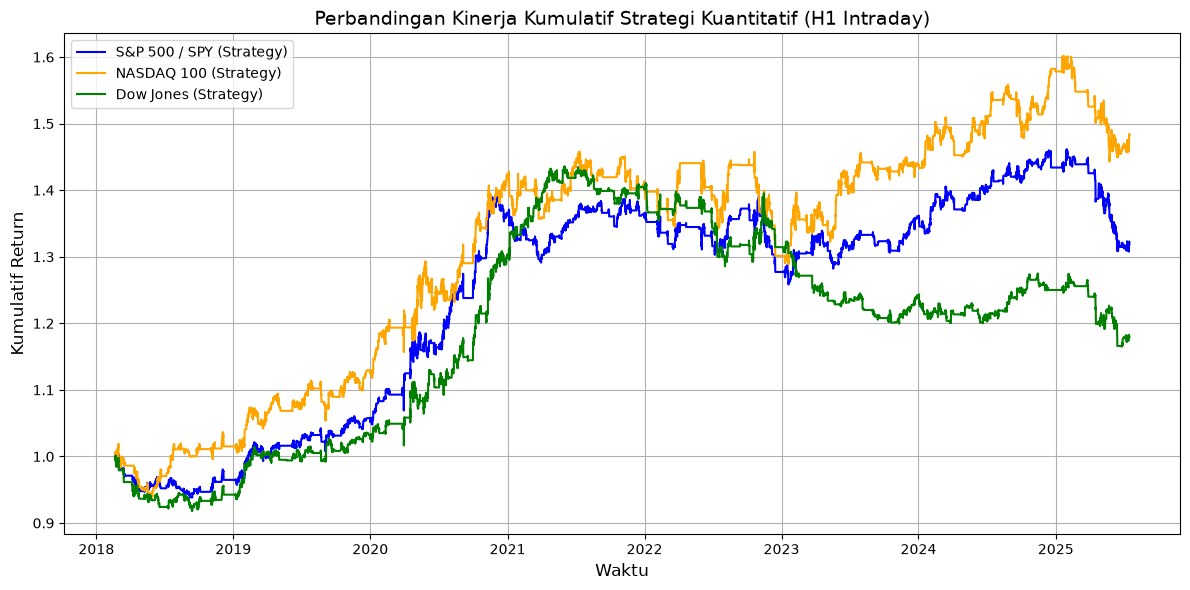

Return Akhir S&P 500 Strategy : 1.32x
Return Akhir NASDAQ Strategy  : 1.48x
Return Akhir Dow Jones Strategy: 1.18x


In [15]:
# ==========================================
# 5. SIMULASI TRADING & VISUALISASI KINERJA
# ==========================================

import matplotlib.pyplot as plt

def jalankan_strategi(df):
    data = df.copy()
    
    # Aturan Sinyal: Beli jika EMA 50 > EMA 200, RSI < 70, MACD > Signal
    kondisi_beli = (data['ema_50'] > data['ema_200']) & (data['rsi'] < 70) & (data['macd'] > data['macd_signal'])
    
    data['posisi'] = 0
    data.loc[kondisi_beli, 'posisi'] = 1
    
    data['market_return'] = data['close'].pct_change()
    data['strategy_return'] = data['posisi'].shift(1) * data['market_return']
    
    # Hitung Cumulative Return
    data['cum_market'] = (1 + data['market_return'].fillna(0)).cumprod()
    data['cum_strategy'] = (1 + data['strategy_return'].fillna(0)).cumprod()
    
    return data

# Terapkan ke data yang sudah selaras
df_spy_res = jalankan_strategi(df_spy_final)
df_ndx_res = jalankan_strategi(df_ndx_final)
df_dji_res = jalankan_strategi(df_dji_final)

# Visualisasi Grafik Perbandingan
plt.figure(figsize=(12, 6))
plt.plot(df_spy_res.index, df_spy_res['cum_strategy'], label='S&P 500 / SPY (Strategy)', color='blue')
plt.plot(df_ndx_res.index, df_ndx_res['cum_strategy'], label='NASDAQ 100 (Strategy)', color='orange')
plt.plot(df_dji_res.index, df_dji_res['cum_strategy'], label='Dow Jones (Strategy)', color='green')

plt.title('Perbandingan Kinerja Kumulatif Strategi Kuantitatif (H1 Intraday)', fontsize=14)
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Kumulatif Return', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Cetak Performa Akhir
print(f"Return Akhir S&P 500 Strategy : {df_spy_res['cum_strategy'].iloc[-1]:.2f}x")
print(f"Return Akhir NASDAQ Strategy  : {df_ndx_res['cum_strategy'].iloc[-1]:.2f}x")
print(f"Return Akhir Dow Jones Strategy: {df_dji_res['cum_strategy'].iloc[-1]:.2f}x")

In [16]:
# Menampilkan sampel baris saat terjadi perubahan posisi (Entry / Exit)
def tampilkan_log_transaksi(df, nama_aset):
    # Filter baris di mana posisi berubah (dari 0 ke 1, atau 1 ke 0)
    df_transaksi = df[df['posisi'] != df['posisi'].shift()].copy()
    df_transaksi['aksi'] = df_transaksi['posisi'].apply(lambda x: 'BUY (Masuk)' if x == 1 else 'SELL (Keluar)')
    
    print(f"--- LOG TRANSAKSI SAMPEL: {nama_aset} ---")
    return df_transaksi[['close', 'rsi', 'macd', 'aksi']].tail(10)

# Cek sampel transaksi untuk SPY
display(tampilkan_log_transaksi(df_spy_res, 'S&P 500 (SPY)'))
print("\n")
# Cek sampel transaksi untuk NASDAQ
display(tampilkan_log_transaksi(df_ndx_res, 'NASDAQ 100'))
print("\n")
display(tampilkan_log_transaksi(df_dji_res, 'Dow Jones Industrial Average'))

--- LOG TRANSAKSI SAMPEL: S&P 500 (SPY) ---


,close,rsi,macd,aksi
datetime,,,,
2025-07-10 17:00:00,6269.5,63.184589,5.101735,BUY (Masuk)
2025-07-10 20:00:00,6287.4,70.290734,8.839117,SELL (Keluar)
2025-07-10 21:00:00,6284.2,67.427526,9.627696,BUY (Masuk)
2025-07-11 03:00:00,6249.1,42.678928,7.303544,SELL (Keluar)
2025-07-11 19:00:00,6264.0,54.629403,-1.469257,BUY (Masuk)
2025-07-14 01:00:00,6236.8,38.282908,-1.997103,SELL (Keluar)
2025-07-14 12:00:00,6241.5,49.286252,-6.074660,BUY (Masuk)
2025-07-15 04:00:00,6285.3,70.729048,7.054669,SELL (Keluar)
2025-07-15 05:00:00,6269.6,57.899564,7.040440,BUY (Masuk)




--- LOG TRANSAKSI SAMPEL: NASDAQ 100 ---


,close,rsi,macd,aksi
datetime,,,,
2025-07-11 17:00:00,22799.7,52.465481,-16.748241,BUY (Masuk)
2025-07-14 01:00:00,22720.8,40.380560,-7.492703,SELL (Keluar)
2025-07-14 12:00:00,22737.8,49.501560,-19.588830,BUY (Masuk)
2025-07-14 20:00:00,22883.0,70.094320,22.732135,SELL (Keluar)
2025-07-14 22:00:00,22871.5,66.249098,31.750874,BUY (Masuk)
2025-07-15 04:00:00,22983.7,74.124990,40.576608,SELL (Keluar)
2025-07-15 05:00:00,22897.7,59.453781,40.761748,BUY (Masuk)
2025-07-15 15:00:00,23037.0,70.287588,60.776521,SELL (Keluar)
2025-07-15 16:00:00,22980.4,59.203746,56.436473,BUY (Masuk)




--- LOG TRANSAKSI SAMPEL: Dow Jones Industrial Average ---


,close,rsi,macd,aksi
datetime,,,,
2025-07-08 08:00:00,44431.0,43.645790,-75.452723,BUY (Masuk)
2025-07-08 21:00:00,44288.3,38.346884,-57.045849,SELL (Keluar)
2025-07-09 07:00:00,44244.4,39.042773,-59.531730,BUY (Masuk)
2025-07-10 06:00:00,44371.4,48.182859,21.095861,SELL (Keluar)
2025-07-10 14:00:00,44472.9,59.466075,12.484695,BUY (Masuk)
2025-07-10 17:00:00,44683.5,70.720364,39.591026,SELL (Keluar)
2025-07-10 21:00:00,44729.5,69.554676,89.358336,BUY (Masuk)
2025-07-11 03:00:00,44451.7,44.179895,63.608187,SELL (Keluar)
2025-07-14 11:00:00,44222.1,41.757256,-70.393238,BUY (Masuk)


In [17]:
# ==========================================
# 6. MODUL EVALUASI METRIK KINERJA SKRIPSI
# ==========================================

import numpy as np

def hitung_metrik_performa(df, nama_aset):
    data = df.copy()
    
    # 1. Total Cumulative Return
    total_return = data['cum_strategy'].iloc[-1] - 1
    
    # 2. Annualized Sharpe Ratio (Asumsi 252 hari perdagangan * 8 jam bursa aktif per tahun untuk H1)
    # Menghitung mean dan std return strategi
    strat_returns = data['strategy_return'].dropna()
    sharpe_ratio = (strat_returns.mean() / strat_returns.std()) * np.sqrt(252 * 8)
    
    # 3. Maximum Drawdown (MDD)
    rolling_max = data['cum_strategy'].cummax()
    drawdown = (data['cum_strategy'] - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # 4. Win Rate (Persentase trade yang menghasilkan profit positif)
    trade_returns = strat_returns[strat_returns != 0]
    win_rate = (trade_returns > 0).sum() / len(trade_returns) if len(trade_returns) > 0 else 0
    
    return {
        'Instrumen': nama_aset,
        'Total Return': f"{total_return * 100:.2f}%",
        'Sharpe Ratio': f"{sharpe_ratio:.4f}",
        'Max Drawdown': f"{max_drawdown * 100:.2f}%",
        'Win Rate': f"{win_rate * 100:.2f}%"
    }

# Menghitung metrik untuk ketiga instrumen
metrik_spy = hitung_metrik_performa(df_spy_res, 'S&P 500 (SPY)')
metrik_ndx = hitung_metrik_performa(df_ndx_res, 'NASDAQ 100')
metrik_dji = hitung_metrik_performa(df_dji_res, 'Dow Jones')

# Menggabungkan ke dalam DataFrame Tabel Ringkasan
tabel_hasil = pd.DataFrame([metrik_spy, metrik_ndx, metrik_dji])
print("--- TABEL RINGKASAN KINERJA STRATEGI UNTUK SKRIPSI ---")
display(tabel_hasil)

--- TABEL RINGKASAN KINERJA STRATEGI UNTUK SKRIPSI ---


,Instrumen,Total Return,Sharpe Ratio,Max Drawdown,Win Rate
0,S&P 500 (SPY),31.93%,0.3762,-10.53%,51.85%
1,NASDAQ 100,48.21%,0.4218,-11.60%,52.84%
2,Dow Jones,17.92%,0.2298,-18.86%,51.35%
